In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8')

print("All libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Matplotlib is building the font cache; this may take a moment.


All libraries loaded successfully!
Pandas version: 2.3.3
NumPy version: 2.4.4


In [2]:
# Load the transaction data
print("Loading dataset... this may take 30-60 seconds")

df_transaction = pd.read_csv('../data/raw/train_transaction.csv')
df_identity = pd.read_csv('../data/raw/train_identity.csv')

print(f"Transaction data shape: {df_transaction.shape}")
print(f"Identity data shape: {df_identity.shape}")
print(f"\nTransaction columns: {df_transaction.shape[1]}")
print(f"Identity columns: {df_identity.shape[1]}")
print(f"\nTotal transactions: {df_transaction.shape[0]:,}")

Loading dataset... this may take 30-60 seconds
Transaction data shape: (590540, 394)
Identity data shape: (144233, 41)

Transaction columns: 394
Identity columns: 41

Total transactions: 590,540


Not Fraud (0): 569,877
Fraud (1):     20,663

Fraud rate: 3.50%
Class imbalance ratio: 28:1


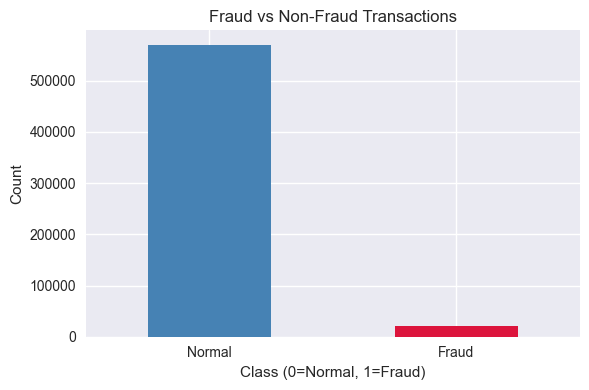

In [3]:
# Check class imbalance
fraud_count = df_transaction['isFraud'].value_counts()
fraud_rate = df_transaction['isFraud'].mean() * 100

print(f"Not Fraud (0): {fraud_count[0]:,}")
print(f"Fraud (1):     {fraud_count[1]:,}")
print(f"\nFraud rate: {fraud_rate:.2f}%")
print(f"Class imbalance ratio: {fraud_count[0]/fraud_count[1]:.0f}:1")

# Visualise
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
fraud_count.plot(kind='bar', ax=ax, color=['steelblue', 'crimson'])
ax.set_title('Fraud vs Non-Fraud Transactions')
ax.set_xlabel('Class (0=Normal, 1=Fraud)')
ax.set_ylabel('Count')
ax.set_xticklabels(['Normal', 'Fraud'], rotation=0)
plt.tight_layout()
plt.show()

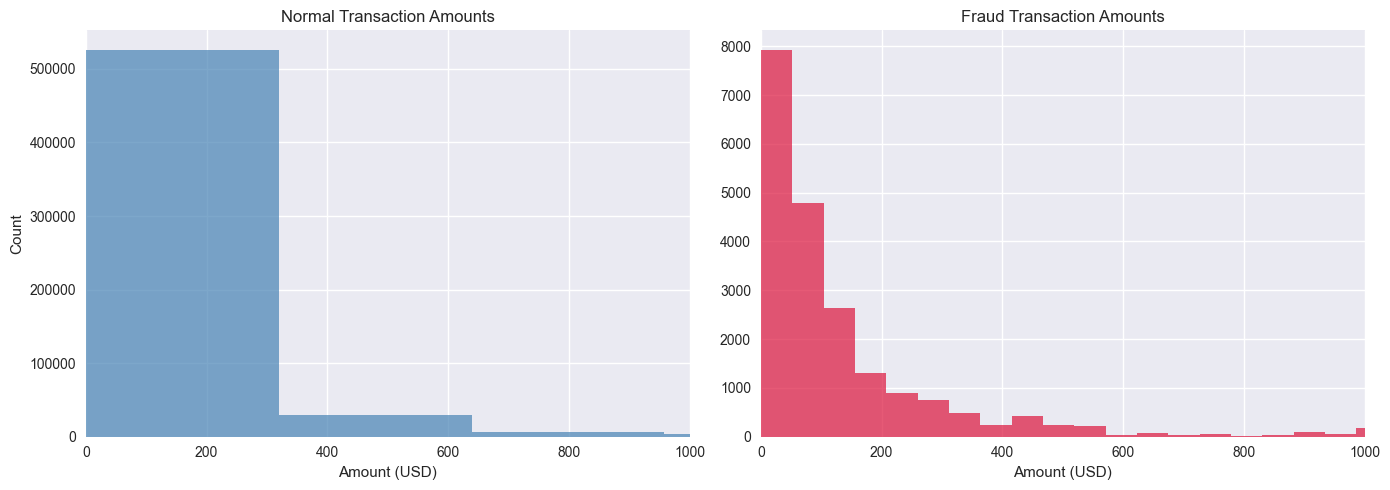

Normal - Mean: $134.51
Fraud  - Mean: $149.24


In [4]:
# Transaction amount analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal transactions
axes[0].hist(df_transaction[df_transaction['isFraud']==0]['TransactionAmt'], 
             bins=100, color='steelblue', alpha=0.7)
axes[0].set_title('Normal Transaction Amounts')
axes[0].set_xlabel('Amount (USD)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 1000)

# Fraud transactions
axes[1].hist(df_transaction[df_transaction['isFraud']==1]['TransactionAmt'], 
             bins=100, color='crimson', alpha=0.7)
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount (USD)')
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.show()

print(f"Normal - Mean: ${df_transaction[df_transaction['isFraud']==0]['TransactionAmt'].mean():.2f}")
print(f"Fraud  - Mean: ${df_transaction[df_transaction['isFraud']==1]['TransactionAmt'].mean():.2f}")

In [5]:
# Missing value analysis
missing = df_transaction.isnull().sum()
missing_pct = (missing / len(df_transaction) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

# Show top 20 columns with most missing values
print("Top 20 columns with most missing values:")
print(missing_df[missing_df['missing_count'] > 0].head(20))

print(f"\nTotal columns with missing values: {(missing > 0).sum()}")
print(f"Total columns with >50% missing: {(missing_pct > 50).sum()}")

Top 20 columns with most missing values:
       missing_count  missing_pct
dist2         552913        93.63
D7            551623        93.41
D13           528588        89.51
D14           528353        89.47
D12           525823        89.04
D6            517353        87.61
D9            515614        87.31
D8            515614        87.31
V153          508595        86.12
V140          508595        86.12
V150          508589        86.12
V149          508595        86.12
V155          508595        86.12
V147          508595        86.12
V146          508595        86.12
V145          508589        86.12
V144          508589        86.12
V143          508589        86.12
V142          508595        86.12
V141          508595        86.12

Total columns with missing values: 374
Total columns with >50% missing: 174


In [6]:
# Basic dataset overview
print("=== DATASET SUMMARY ===")
print(f"\nTotal transactions: {len(df_transaction):,}")
print(f"Fraud transactions: {df_transaction['isFraud'].sum():,}")
print(f"Fraud rate: {df_transaction['isFraud'].mean()*100:.2f}%")
print(f"Class imbalance: {(1-df_transaction['isFraud'].mean())/df_transaction['isFraud'].mean():.0f}:1")
print(f"\nTotal features: {df_transaction.shape[1]}")
print(f"Features with missing values: 374")
print(f"Features with >50% missing: 174")
print(f"\nTransaction amount range: ${df_transaction['TransactionAmt'].min():.2f} - ${df_transaction['TransactionAmt'].max():,.2f}")
print(f"Mean fraud amount: $149.24")
print(f"Mean normal amount: $134.51")

print("\n=== KEY FINDINGS FOR EDA ===")
print("1. Severe class imbalance (28:1) - must use AUC-ROC not accuracy")
print("2. 174 features >50% missing - need careful imputation strategy")
print("3. Fraud transactions slightly higher value on average")
print("4. Both distributions heavily right-skewed - consider log transform")


=== DATASET SUMMARY ===

Total transactions: 590,540
Fraud transactions: 20,663
Fraud rate: 3.50%
Class imbalance: 28:1

Total features: 394
Features with missing values: 374
Features with >50% missing: 174

Transaction amount range: $0.25 - $31,937.39
Mean fraud amount: $149.24
Mean normal amount: $134.51

=== KEY FINDINGS FOR EDA ===
1. Severe class imbalance (28:1) - must use AUC-ROC not accuracy
2. 174 features >50% missing - need careful imputation strategy
3. Fraud transactions slightly higher value on average
4. Both distributions heavily right-skewed - consider log transform


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8')

# Reload data
print("Loading data...")
df_transaction = pd.read_csv('../data/raw/train_transaction.csv')
df_identity = pd.read_csv('../data/raw/train_identity.csv')
print(f"Loaded {len(df_transaction):,} transactions")

Loading data...
Loaded 590,540 transactions


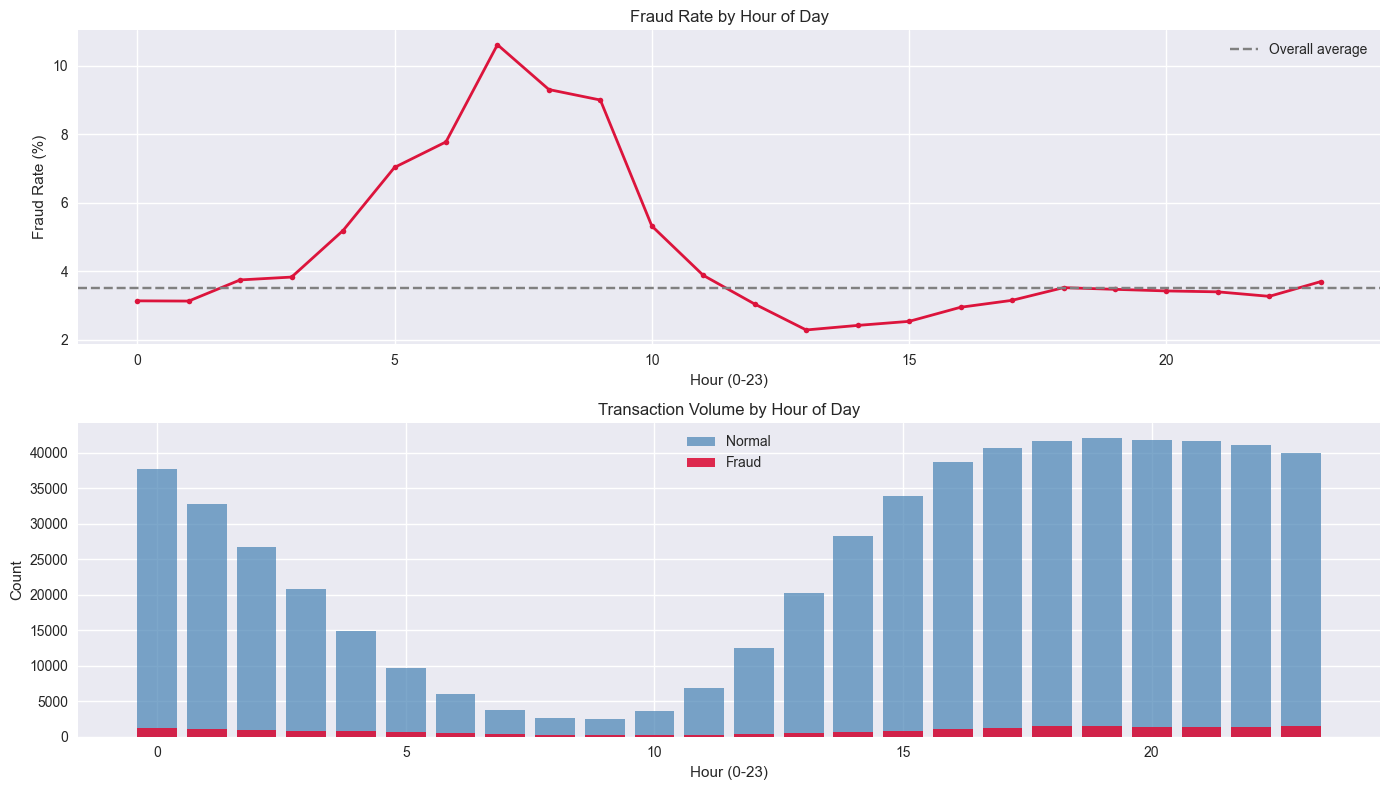

Peak fraud hour: 7:00 (10.61% fraud rate)
Lowest fraud hour: 13:00 (2.29% fraud rate)


In [2]:
# Fraud patterns by time of day
# TransactionDT is seconds from a reference point
df_transaction['hour'] = (df_transaction['TransactionDT'] // 3600) % 24

hourly = df_transaction.groupby('hour')['isFraud'].agg(['sum', 'count', 'mean'])
hourly.columns = ['fraud_count', 'total_count', 'fraud_rate']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Fraud rate by hour
axes[0].plot(hourly.index, hourly['fraud_rate'] * 100, 
             color='crimson', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].axhline(y=df_transaction['isFraud'].mean()*100, 
                color='gray', linestyle='--', label='Overall average')
axes[0].legend()

# Transaction volume by hour
axes[1].bar(hourly.index, hourly['total_count'], 
            color='steelblue', alpha=0.7, label='Normal')
axes[1].bar(hourly.index, hourly['fraud_count'], 
            color='crimson', alpha=0.9, label='Fraud')
axes[1].set_title('Transaction Volume by Hour of Day')
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Peak fraud hour: {hourly['fraud_rate'].idxmax()}:00 "
      f"({hourly['fraud_rate'].max()*100:.2f}% fraud rate)")
print(f"Lowest fraud hour: {hourly['fraud_rate'].idxmin()}:00 "
      f"({hourly['fraud_rate'].min()*100:.2f}% fraud rate)")

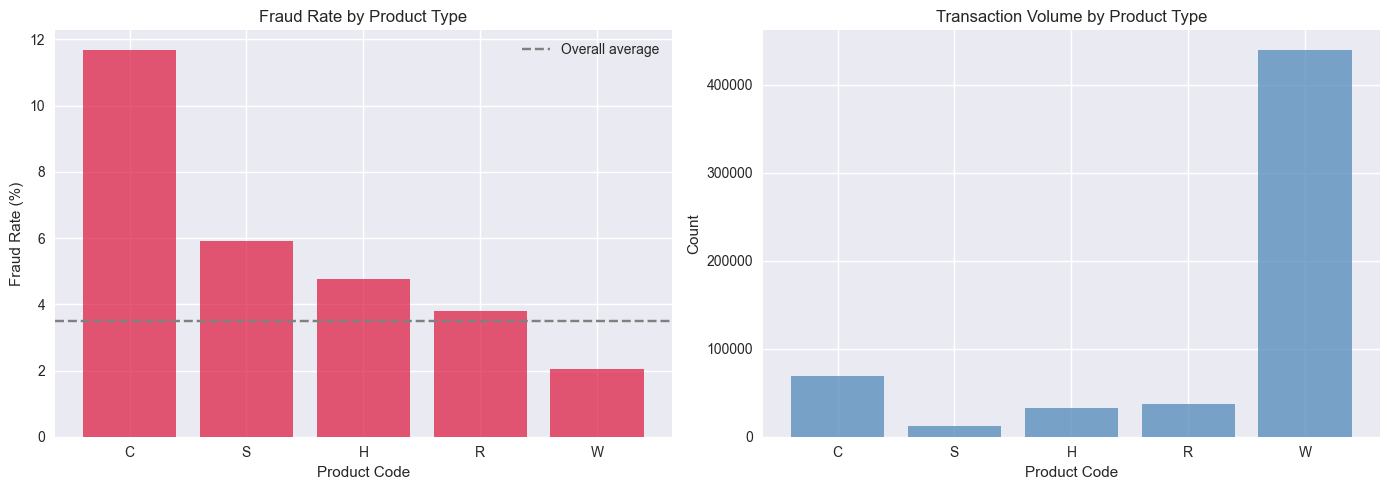

Fraud rate by product:
           fraud_rate   count
ProductCD                    
C            0.116873   68519
S            0.058996   11628
H            0.047662   33024
R            0.037826   37699
W            0.020399  439670


In [3]:
# Fraud by product type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate by ProductCD
product_fraud = df_transaction.groupby('ProductCD')['isFraud'].agg(['mean', 'count'])
product_fraud.columns = ['fraud_rate', 'count']
product_fraud = product_fraud.sort_values('fraud_rate', ascending=False)

axes[0].bar(product_fraud.index, product_fraud['fraud_rate'] * 100, 
            color='crimson', alpha=0.7)
axes[0].set_title('Fraud Rate by Product Type')
axes[0].set_xlabel('Product Code')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].axhline(y=df_transaction['isFraud'].mean()*100, 
                color='gray', linestyle='--', label='Overall average')
axes[0].legend()

# Transaction count by ProductCD
axes[1].bar(product_fraud.index, product_fraud['count'], 
            color='steelblue', alpha=0.7)
axes[1].set_title('Transaction Volume by Product Type')
axes[1].set_xlabel('Product Code')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("Fraud rate by product:")
print(product_fraud[['fraud_rate', 'count']].to_string())

Top 15 features most correlated with fraud:
V257    0.3831
V246    0.3669
V244    0.3641
V242    0.3606
V201    0.3280
V200    0.3188
V189    0.3082
V188    0.3036
V258    0.2972
V45     0.2818
V158    0.2781
V156    0.2760
V149    0.2733
V228    0.2689
V44     0.2604
Name: isFraud, dtype: float64


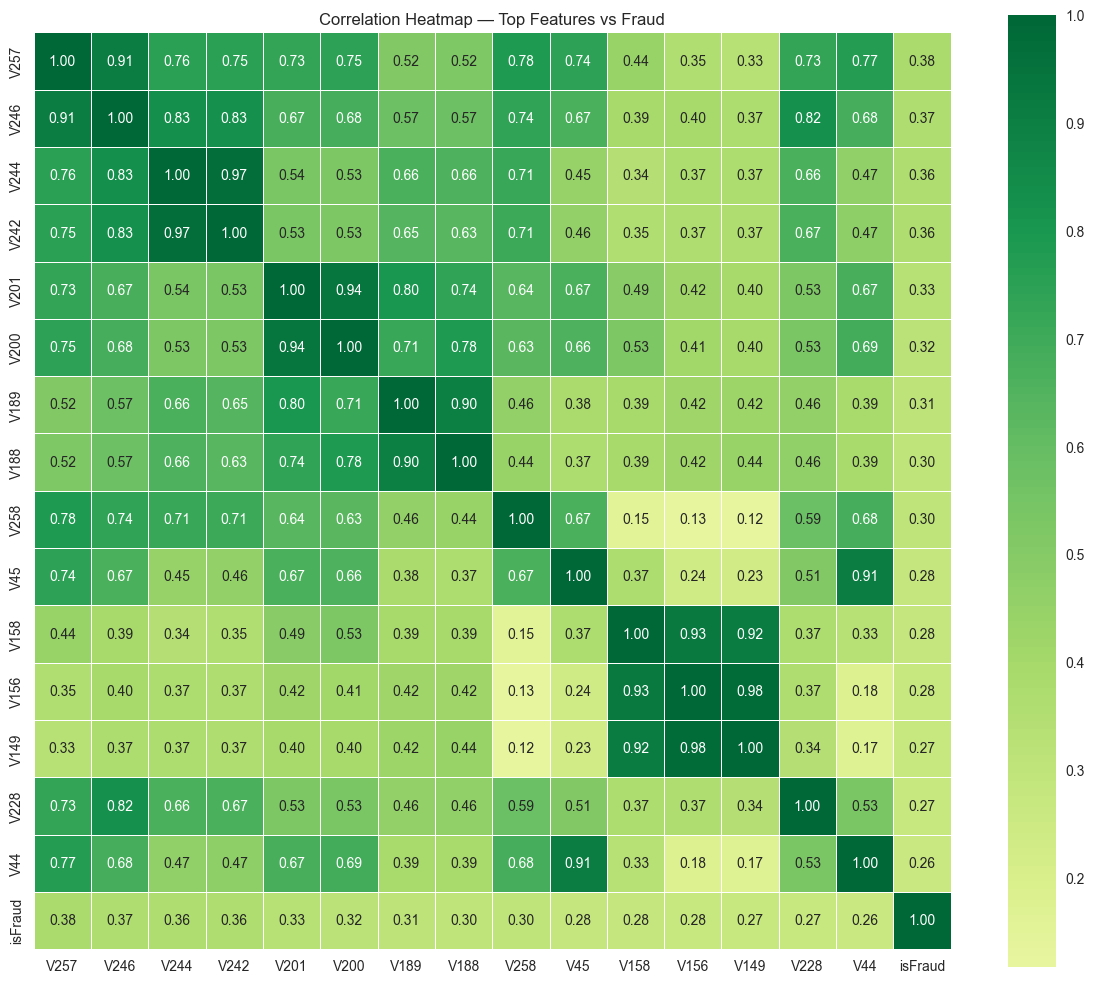

In [4]:
# Correlation heatmap of numeric features with isFraud
numeric_cols = df_transaction.select_dtypes(include=[np.number]).columns.tolist()

# Get top 15 most correlated features with isFraud
correlations = df_transaction[numeric_cols].corr()['isFraud'].abs()
correlations = correlations.drop('isFraud').sort_values(ascending=False)
top_features = correlations.head(15).index.tolist()

print("Top 15 features most correlated with fraud:")
print(correlations.head(15).round(4))

# Heatmap of top features
top_corr_matrix = df_transaction[top_features + ['isFraud']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(top_corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap — Top Features vs Fraud')
plt.tight_layout()
plt.show()

In [5]:
# Final EDA summary
print("=" * 50)
print("EDA COMPLETE — KEY FINDINGS SUMMARY")
print("=" * 50)
print(f"\n1. DATASET SIZE")
print(f"   - 590,540 transactions, 394 features")
print(f"   - 20,663 fraud cases (3.5% fraud rate)")
print(f"   - Class imbalance: 28:1")

print(f"\n2. TIME PATTERNS")
print(f"   - Peak fraud hour: 7AM (10.6% fraud rate)")
print(f"   - Safest hour: 1PM (2.3% fraud rate)")
print(f"   - Hour-of-day is a strong feature candidate")

print(f"\n3. PRODUCT PATTERNS")
print(f"   - Product C: highest fraud rate (11.7%)")
print(f"   - Product W: lowest fraud rate (2.0%)")
print(f"   - ProductCD is a strong categorical feature")

print(f"\n4. MISSING VALUES")
print(f"   - 374/394 features have missing values")
print(f"   - 174 features have >50% missing")
print(f"   - Strategy: median imputation + missing indicator flags")

print(f"\n5. TOP CORRELATED FEATURES")
print(f"   - V257, V246, V244, V242 most correlated with fraud")
print(f"   - V158/V156/V149 highly correlated (redundant)")
print(f"   - TransactionAmt has weak direct correlation")

print(f"\nNEXT STEPS (Thursday):")
print(f"   - Feature engineering: velocity, log transforms")
print(f"   - Merge transaction + identity data")
print(f"   - Build preprocessing pipeline")

EDA COMPLETE — KEY FINDINGS SUMMARY

1. DATASET SIZE
   - 590,540 transactions, 394 features
   - 20,663 fraud cases (3.5% fraud rate)
   - Class imbalance: 28:1

2. TIME PATTERNS
   - Peak fraud hour: 7AM (10.6% fraud rate)
   - Safest hour: 1PM (2.3% fraud rate)
   - Hour-of-day is a strong feature candidate

3. PRODUCT PATTERNS
   - Product C: highest fraud rate (11.7%)
   - Product W: lowest fraud rate (2.0%)
   - ProductCD is a strong categorical feature

4. MISSING VALUES
   - 374/394 features have missing values
   - 174 features have >50% missing
   - Strategy: median imputation + missing indicator flags

5. TOP CORRELATED FEATURES
   - V257, V246, V244, V242 most correlated with fraud
   - V158/V156/V149 highly correlated (redundant)
   - TransactionAmt has weak direct correlation

NEXT STEPS (Thursday):
   - Feature engineering: velocity, log transforms
   - Merge transaction + identity data
   - Build preprocessing pipeline
